1. Install packages

In [ ]:
%pip install -q pyvi
%pip install -q "huggingface_hub>=0.20"
print("Dependencies ready.")

Dependencies ready.


In [ ]:
%pip install -q datasets

2. Imports and config

In [ ]:
import math, random, time, warnings
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report
warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
  random.seed(s)
  np.random.seed(s)
  torch.manual_seed(s)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print("Pytorch:", torch.__version__, "| Device:", DEVICE)

LABEL_NAMES = ["negative", "neutral", "positive"]

CONFIG = dict(
    EMBED_DIM = 200,
    LSTM_HIDDEN = 128,
    CNN_REGION_SIZES = (3, 5, 7),
    CNN_NUM_FILTERS = 150,
    CNN_PENULT_DIM = 100,
    NUM_CLASSES = 3,
    LR = 0.002,
    N_FOLDS = 5,
    MAX_LEN = 50,
    MIN_FREQ = 1,
    BATCH_SIZE = 32,
    MAX_EPOCHS = 30,
    PATIENCE = 3,
    VAL_RATIO = 0.1,
    SEG_MODES = ("without_token", "with_token"),
    QUICK_TEST = False
)

if CONFIG["QUICK_TEST"]:
  CONFIG.updaet(N_FOLDS=2, MAX_EPOCS=4, PATIENCE=2)
  print("Quick test")

CONFIG

Using device: cuda
Pytorch: 2.11.0+cu128 | Device: cuda


{'EMBED_DIM': 200,
 'LSTM_HIDDEN': 128,
 'CNN_REGION_SIZES': (3, 5, 7),
 'CNN_NUM_FILTERS': 150,
 'CNN_PENULT_DIM': 100,
 'NUM_CLASSES': 3,
 'LR': 0.002,
 'N_FOLDS': 5,
 'MAX_LEN': 50,
 'MIN_FREQ': 1,
 'BATCH_SIZE': 32,
 'MAX_EPOCHS': 30,
 'PATIENCE': 3,
 'VAL_RATIO': 0.1,
 'SEG_MODES': ('without_token', 'with_token'),
 'QUICK_TEST': False}

3. Load the data

In [ ]:
from huggingface_hub import hf_hub_download

REPO_ID  = "uitnlp/vietnamese_students_feedback"
REVISION = "refs/convert/parquet"

def load_uit_vsfc():
  parts = []
  for split in ["train", "validation", "test"]:
    path = hf_hub_download(
        repo_id=REPO_ID,
        repo_type="dataset",
        revision=REVISION,
        filename=f"default/{split}/0000.parquet"
    )
    d = pd.read_parquet(path)
    d["orig_split"] = split
    parts.append(d)
  df = pd.concat(parts, ignore_index=True)
  df = df.rename(columns={"sentiment": "label"})[["sentence", "label", "orig_split"]]
  df["sentence"] = df["sentence"].fillna("").astype(str)
  df = df[df["sentence"].str.strip() != ""].reset_index(drop=True)
  return df

df = load_uit_vsfc()
print("Total examples:", len(df))
print("Per-split counts:\n", df["orig_split"].value_counts())
print("Class distribution:", df["label"].value_counts().sort_index())

Total examples: 16175
Per-split counts:
 orig_split
train         11426
test           3166
validation     1583
Name: count, dtype: int64
Class distribution: label
0    7439
1     698
2    8038
Name: count, dtype: int64


4. Preprocessing
- without_token: keep the text as is
- with_token: run pyvi word segmentation first, which joins syllables into words (for example "sinh vien" becomes "sinh_vien")

In [ ]:
_SEG = None
def get_segmenter():
  global _SEG
  if _SEG is None:
    from pyvi import ViTokenizer
    _SEG = ViTokenizer.tokenize
  return _SEG

def preprocess(texts, mode):
  texts = [("" if t is None else str(t)) for t in texts]
  if mode == "with_token":
    seg = get_segmenter()
    return [seg(t) for t in texts]
  return texts

def tokenize(text):
  return text.split()

PAD, UNK = "<pad>", "<unk>"
def build_vocab(token_lists, min_freq=1):
  c = Counter(tok for toks in token_lists for tok in toks)
  itos = [PAD, UNK] + [w for w, f in c.items() if f >= min_freq]
  stoi = {w: i for i, w in enumerate(itos)}
  return stoi, itos

def encode(tokens, stoi, max_len):
  ids = [stoi.get(t, 1) for t in tokens[:max_len]]
  if len(ids) < max_len:
    ids += [0] * (max_len - len(ids))
  return ids

class SentDataset(Dataset):
    def __init__(self, token_lists, labels, stoi, max_len):
        self.X = [encode(t, stoi, max_len) for t in token_lists]
        self.y = list(labels)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return (torch.tensor(self.X[i], dtype=torch.long),
                torch.tensor(self.y[i], dtype=torch.long))
print("Preprocessing utilities ready.")

Preprocessing utilities ready.


# Sample Data Flow — `build_vocab` & `encode`

Starting corpus (already tokenized — note pyvi joins compounds with `_`):

```python
token_lists = [
  ["tôi", "yêu", "hà_nội"],
  ["tôi", "yêu", "việt_nam"],
]
```

## 1. Count (`Counter`)

```
tôi: 2,  yêu: 2,  hà_nội: 1,  việt_nam: 1
```

## 2. Build `itos` (with `min_freq=1`, all words kept)

```
index:  0        1        2      3      4         5
itos:  <pad>    <unk>    tôi    yêu   hà_nội   việt_nam
```

## 3. Build `stoi` (just inverted)

```python
{"<pad>": 0, "<unk>": 1, "tôi": 2, "yêu": 3, "hà_nội": 4, "việt_nam": 5}
```

## 4. Encode a new sentence — including an unseen word, with `max_len=5`

```python
encode(["tôi", "ghét", "hà_nội"], stoi, max_len=5)

  tôi    → 2
  ghét   → not in vocab → 1   (<unk>)
  hà_nội → 4

  ids = [2, 1, 4]
```

## 5. Pad to length 5 (the step `encode` usually finishes with)

```
[2, 1, 4, 0, 0]
        ^  ^  ^
        |  └──┴─ <pad> filler
        └─ <unk> for "ghét"
```


5. Model
A shared embedding feeds two branches
- CNN branch: convolution filters of size 3, 5, 7, max-pool each one, concatenate them, then a dense layer
- LSTM branch: take the hidden state at the last real word.

The two feature vectors are concatenated and a linear layer gives the 3 class scores.

In [ ]:
class CNNFeature(nn.Module):
  def __init__(self, embed_dim, region_sizes, num_filters, penult_dim):
    super().__init__()
    self.convs = nn.ModuleList(
        [nn.Conv1d(embed_dim, num_filters, k) for k in region_sizes]
    )
    self.fc = nn.Linear(num_filters * len(region_sizes), penult_dim)
    self.act = nn.ReLU()
  def forward(self, emb):
    x = emb.transpose(1, 2)
    feats = []
    for conv in self.convs:
      c = self.act(conv(x))
      feats.append(torch.max(c, dim=2).values)
    cat = torch.cat(feats, dim=1)
    return self.act(self.fc(cat))

def _last_lstm_output(out, lengths):
  idx = (lengths - 1)
  return out[torch.arange(out.size(0), device=out.device), idx]

class MultiChannelModel(nn.Module):
  def __init__(self, vocab_size, cfg):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, cfg["EMBED_DIM"], padding_idx=0)
    self.lstm = nn.LSTM(cfg["EMBED_DIM"], cfg["LSTM_HIDDEN"], batch_first=True)
    self.cnn = CNNFeature(cfg["EMBED_DIM"], cfg["CNN_REGION_SIZES"], cfg["CNN_NUM_FILTERS"], cfg["CNN_PENULT_DIM"])
    self.classifier = nn.Linear(cfg["LSTM_HIDDEN"] + cfg["CNN_PENULT_DIM"], cfg["NUM_CLASSES"])
  def forward(self, x):
    emb = self.embedding(x)
    lengths = (x != 0).sum(1).clamp(min=1)
    out, _ = self.lstm(emb)
    lstm_feat = _last_lstm_output(out, lengths)
    cnn_feat = self.cnn(emb)
    fused = torch.cat([lstm_feat, cnn_feat], dim=1)
    return self.classifier(fused)
  print ("Model defined")


Model defined


#Sample Data Flow
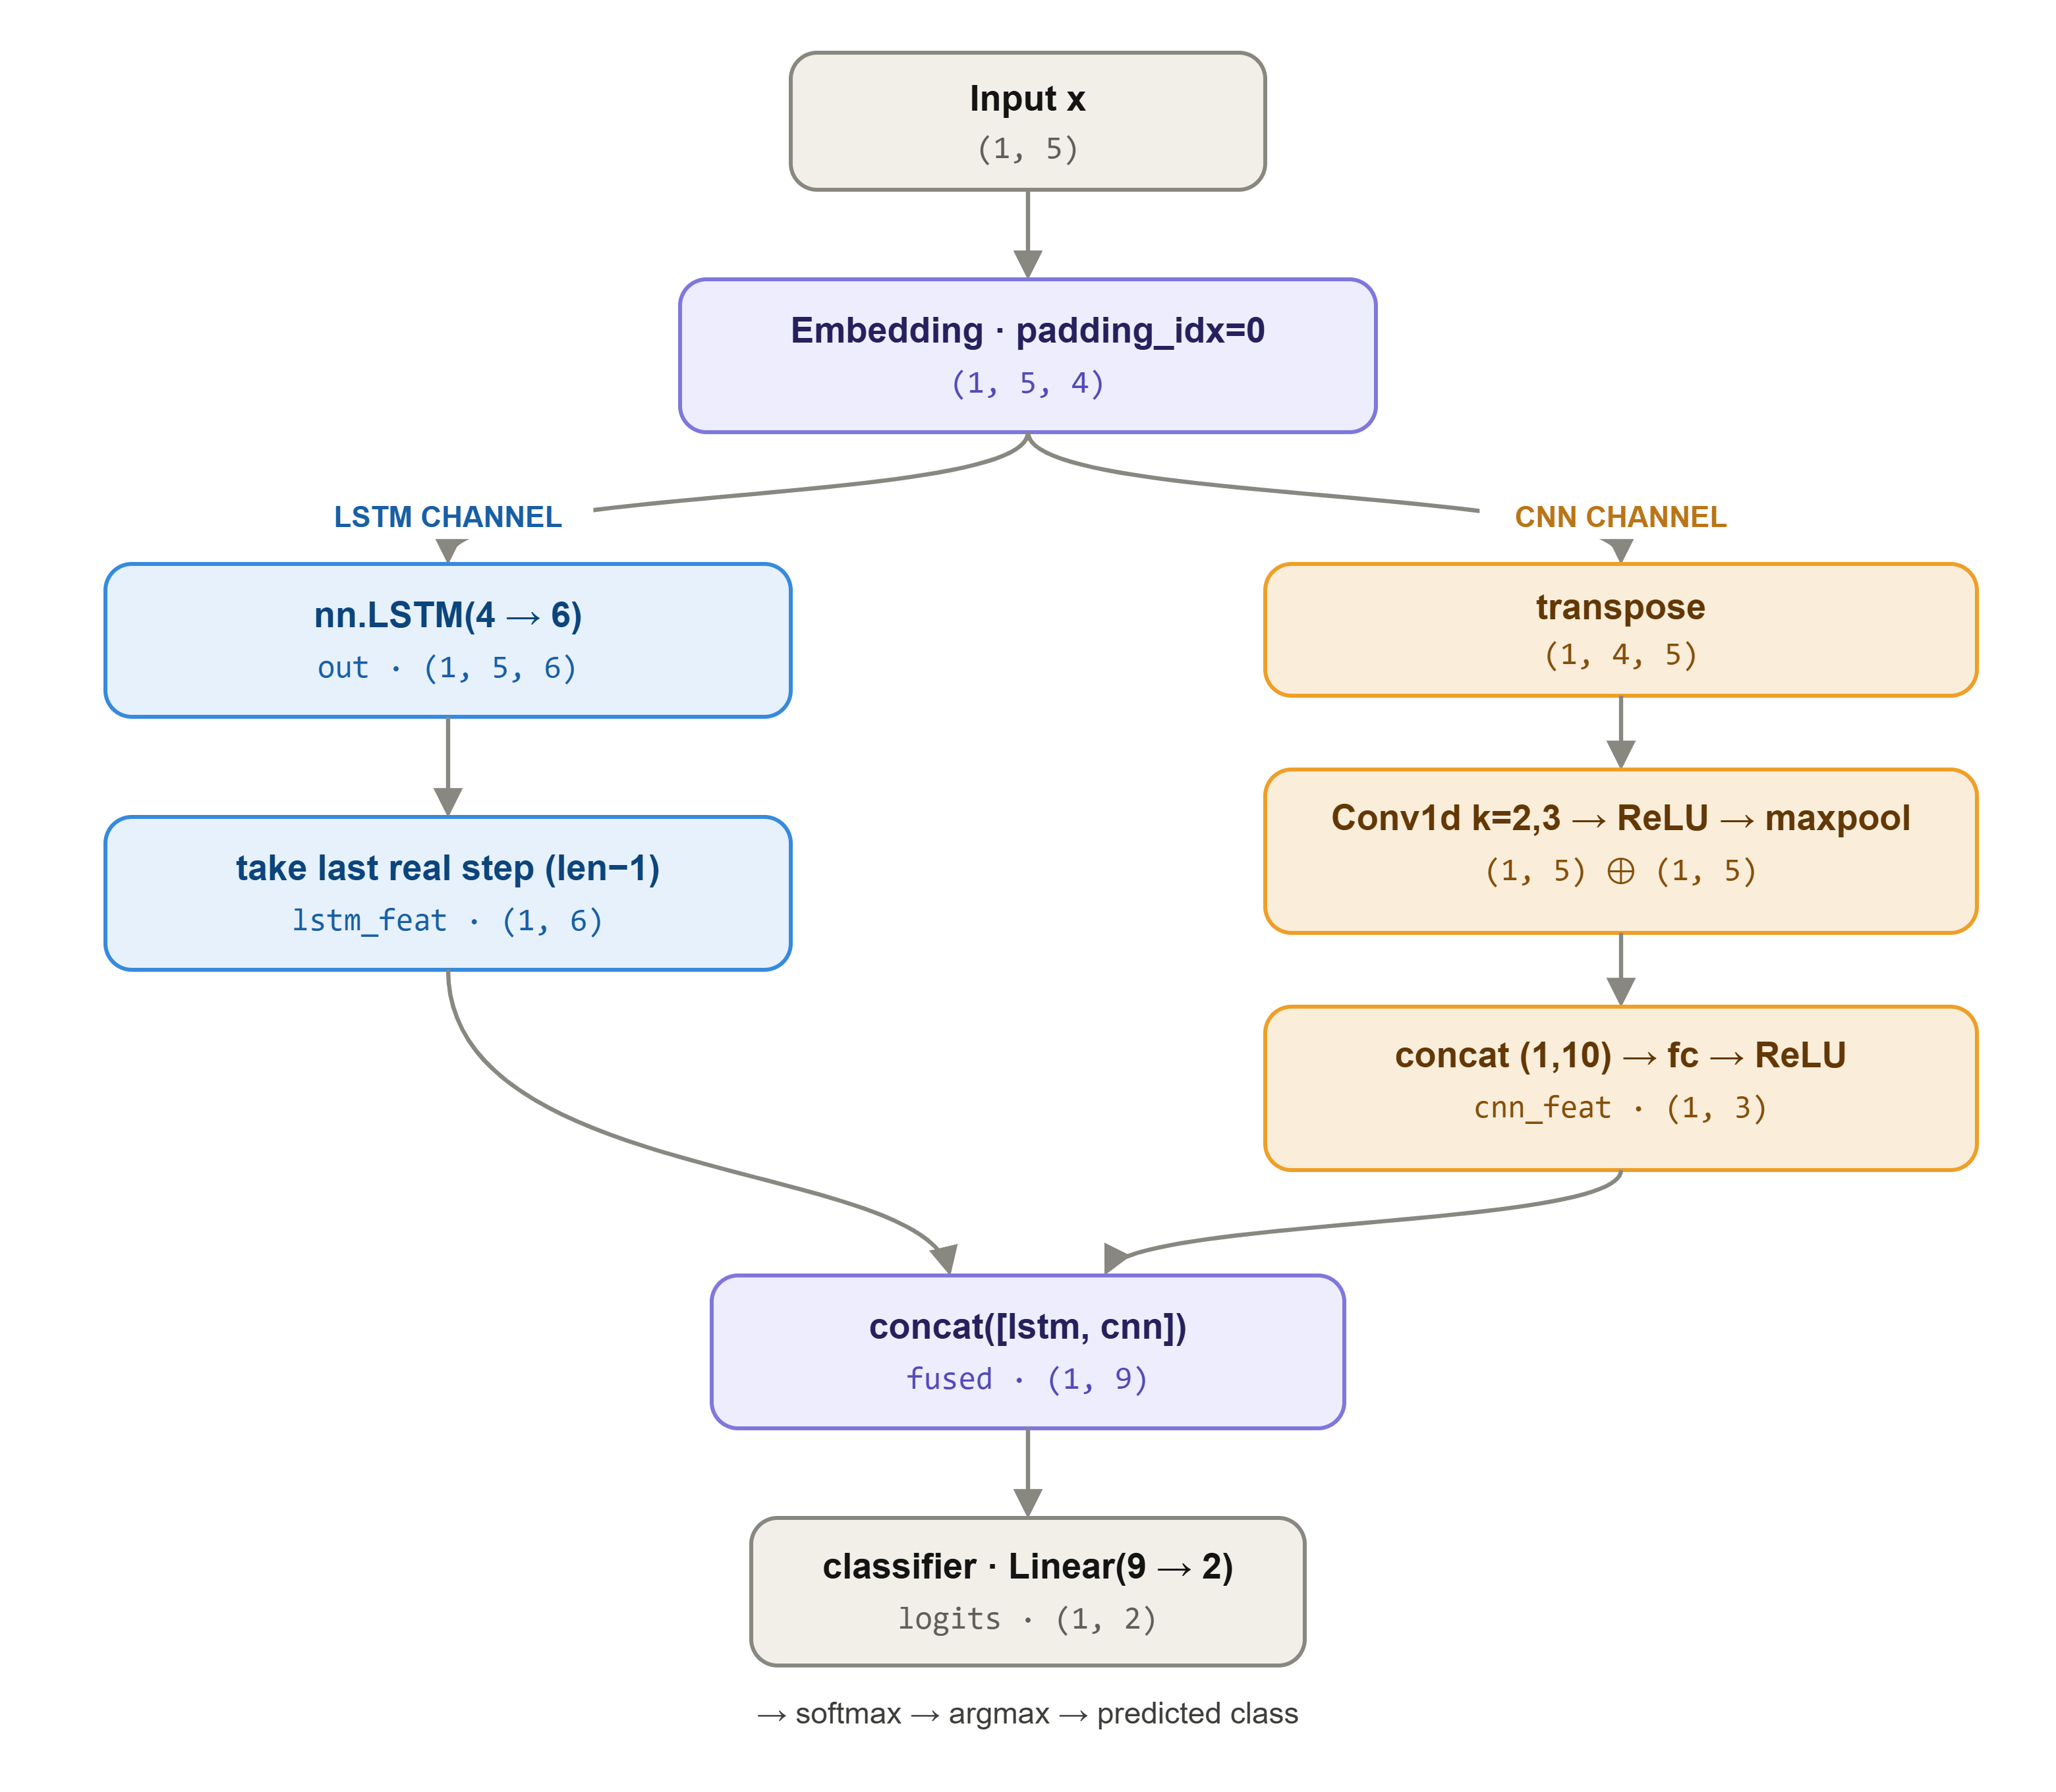

6. Training

Adamax optimizer with cross entropy loss. Stop early when the validation loss stops improving

In [ ]:
def train_model(model, train_ds, val_ds, cfg):
  model = model.to(DEVICE)
  opt = torch.optim.Adamax(model.parameters(), lr=cfg["LR"])
  crit = nn.CrossEntropyLoss()
  tl = DataLoader(train_ds, batch_size=cfg["BATCH_SIZE"], shuffle=True)
  vl = DataLoader(train_ds, batch_size=cfg["BATCH_SIZE"])
  best, best_state, pattience = math.inf, None, 0
  for epoch in range(cfg["MAX_EPOCHS"]):
    model.train()
    for xb, yb in tl:
      xb, yb = xb.to(DEVICE), yb.to(DEVICE)
      opt.zero_grad()
      loss = crit(model(xb), yb)
      loss.backward()
      opt.step()
    model.eval()
    vloss, n = 0.0, 0
    with torch.no_grad():
      for xb, yb in vl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        vloss += crit(model(xb), yb).item() * len(yb)
        n += len(yb)
    vloss /= max(n, 1)
    if vloss < best - 1e-4:
      best, patience = vloss, 0
      best_state = {
          k: v.detach().cpu().clone() for k, v in model.state_dict().items()
      }
    else:
      patience += 1
      if patience >= cfg["PATIENCE"]:
        break
  if best_state is not None:
    model.load_state_dict(best_state)
  return model

def predict(model, ds, cfg):
  model.eval()
  dl = DataLoader(ds, batch_size=cfg["BATCH_SIZE"])
  preds = []
  with torch.no_grad():
    for xb, _ in dl:
      preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
  return np.concatenate(preds)
print("Training utilities ready")

Training utilities ready


7. Cross-validation

For each fold, build the vocab on the training part, take a small slice for early-stopping validation, train the model, and test on the held-out fold.

In [ ]:
def run_cv(df, mode, cfg, verbose=True):
  set_seed()
  t0 = time.time()
  if verbose:
    print(f"\nPreprocessing [{mode}]")
  texts = preprocess(df["sentence"].tolist(), mode)
  token_lists = [tokenize(t) for t in texts]
  labels = df["label"].to_numpy()
  if verbose:
    print(f"corpus used: {len(labels)} sentences | class counts (neg, neu, pos) = "
        f"{np.bincount(labels, minlength=3).tolist()}"
    )
  skf = StratifiedKFold(n_splits=cfg["N_FOLDS"], shuffle=True, random_state=SEED)

  fold_acc, y_true_all, y_pred_all = [], [], []
  for fold, (tr, te) in enumerate(skf.split(token_lists, labels)):
    tr_tokens = [token_lists[i] for i in tr]
    stoi, _ = build_vocab(tr_tokens, cfg["MIN_FREQ"])
    y_tr_all, y_te = labels[tr], labels[te]
    tr2, va2 = train_test_split(
        np.arange(len(tr)), test_size=cfg["VAL_RATIO"],
        random_state=SEED, stratify=y_tr_all
    )
    tr_ds = SentDataset([tr_tokens[i] for i in tr2], y_tr_all[tr2], stoi, cfg["MAX_LEN"])
    va_ds = SentDataset([tr_tokens[i] for i in va2], y_tr_all[va2], stoi, cfg["MAX_LEN"])
    te_ds = SentDataset([token_lists[i] for i in te], y_te, stoi, cfg["MAX_LEN"])
    if verbose and fold == 0:
          print(f"  per-fold sizes -> train {len(tr_ds)}, val {len(va_ds)}, "
                f"test {len(te_ds)} | vocab {len(stoi)}")
    set_seed(SEED + fold)
    model = MultiChannelModel(len(stoi), cfg)
    model = train_model(model, tr_ds, va_ds, cfg)
    pred = predict(model, te_ds, cfg)

    a = accuracy_score(y_te, pred)
    fold_acc.append(a)
    y_true_all.extend(list(y_te))
    y_pred_all.extend(list(pred))

    if verbose:
      print(f"  fold {fold+1}/{cfg['N_FOLDS']}  accuracy = {a*100:5.2f}%")
  mean = float(np.mean(fold_acc)) * 100
  std = float(np.std(fold_acc)) * 100
  report = classification_report(y_true_all, y_pred_all, target_names=LABEL_NAMES, digits=3, zero_division=0)

  if verbose:
    print(f"[{mode}] mean accuracy = {mean:.2f} +/- {std:.2f} ({time.time() - t0:.0f}s)")
  return dict(mean=mean, std=std, report=report, fold_acc=fold_acc)
print("CV harness ready.")


CV harness ready.


## Example Training Flow
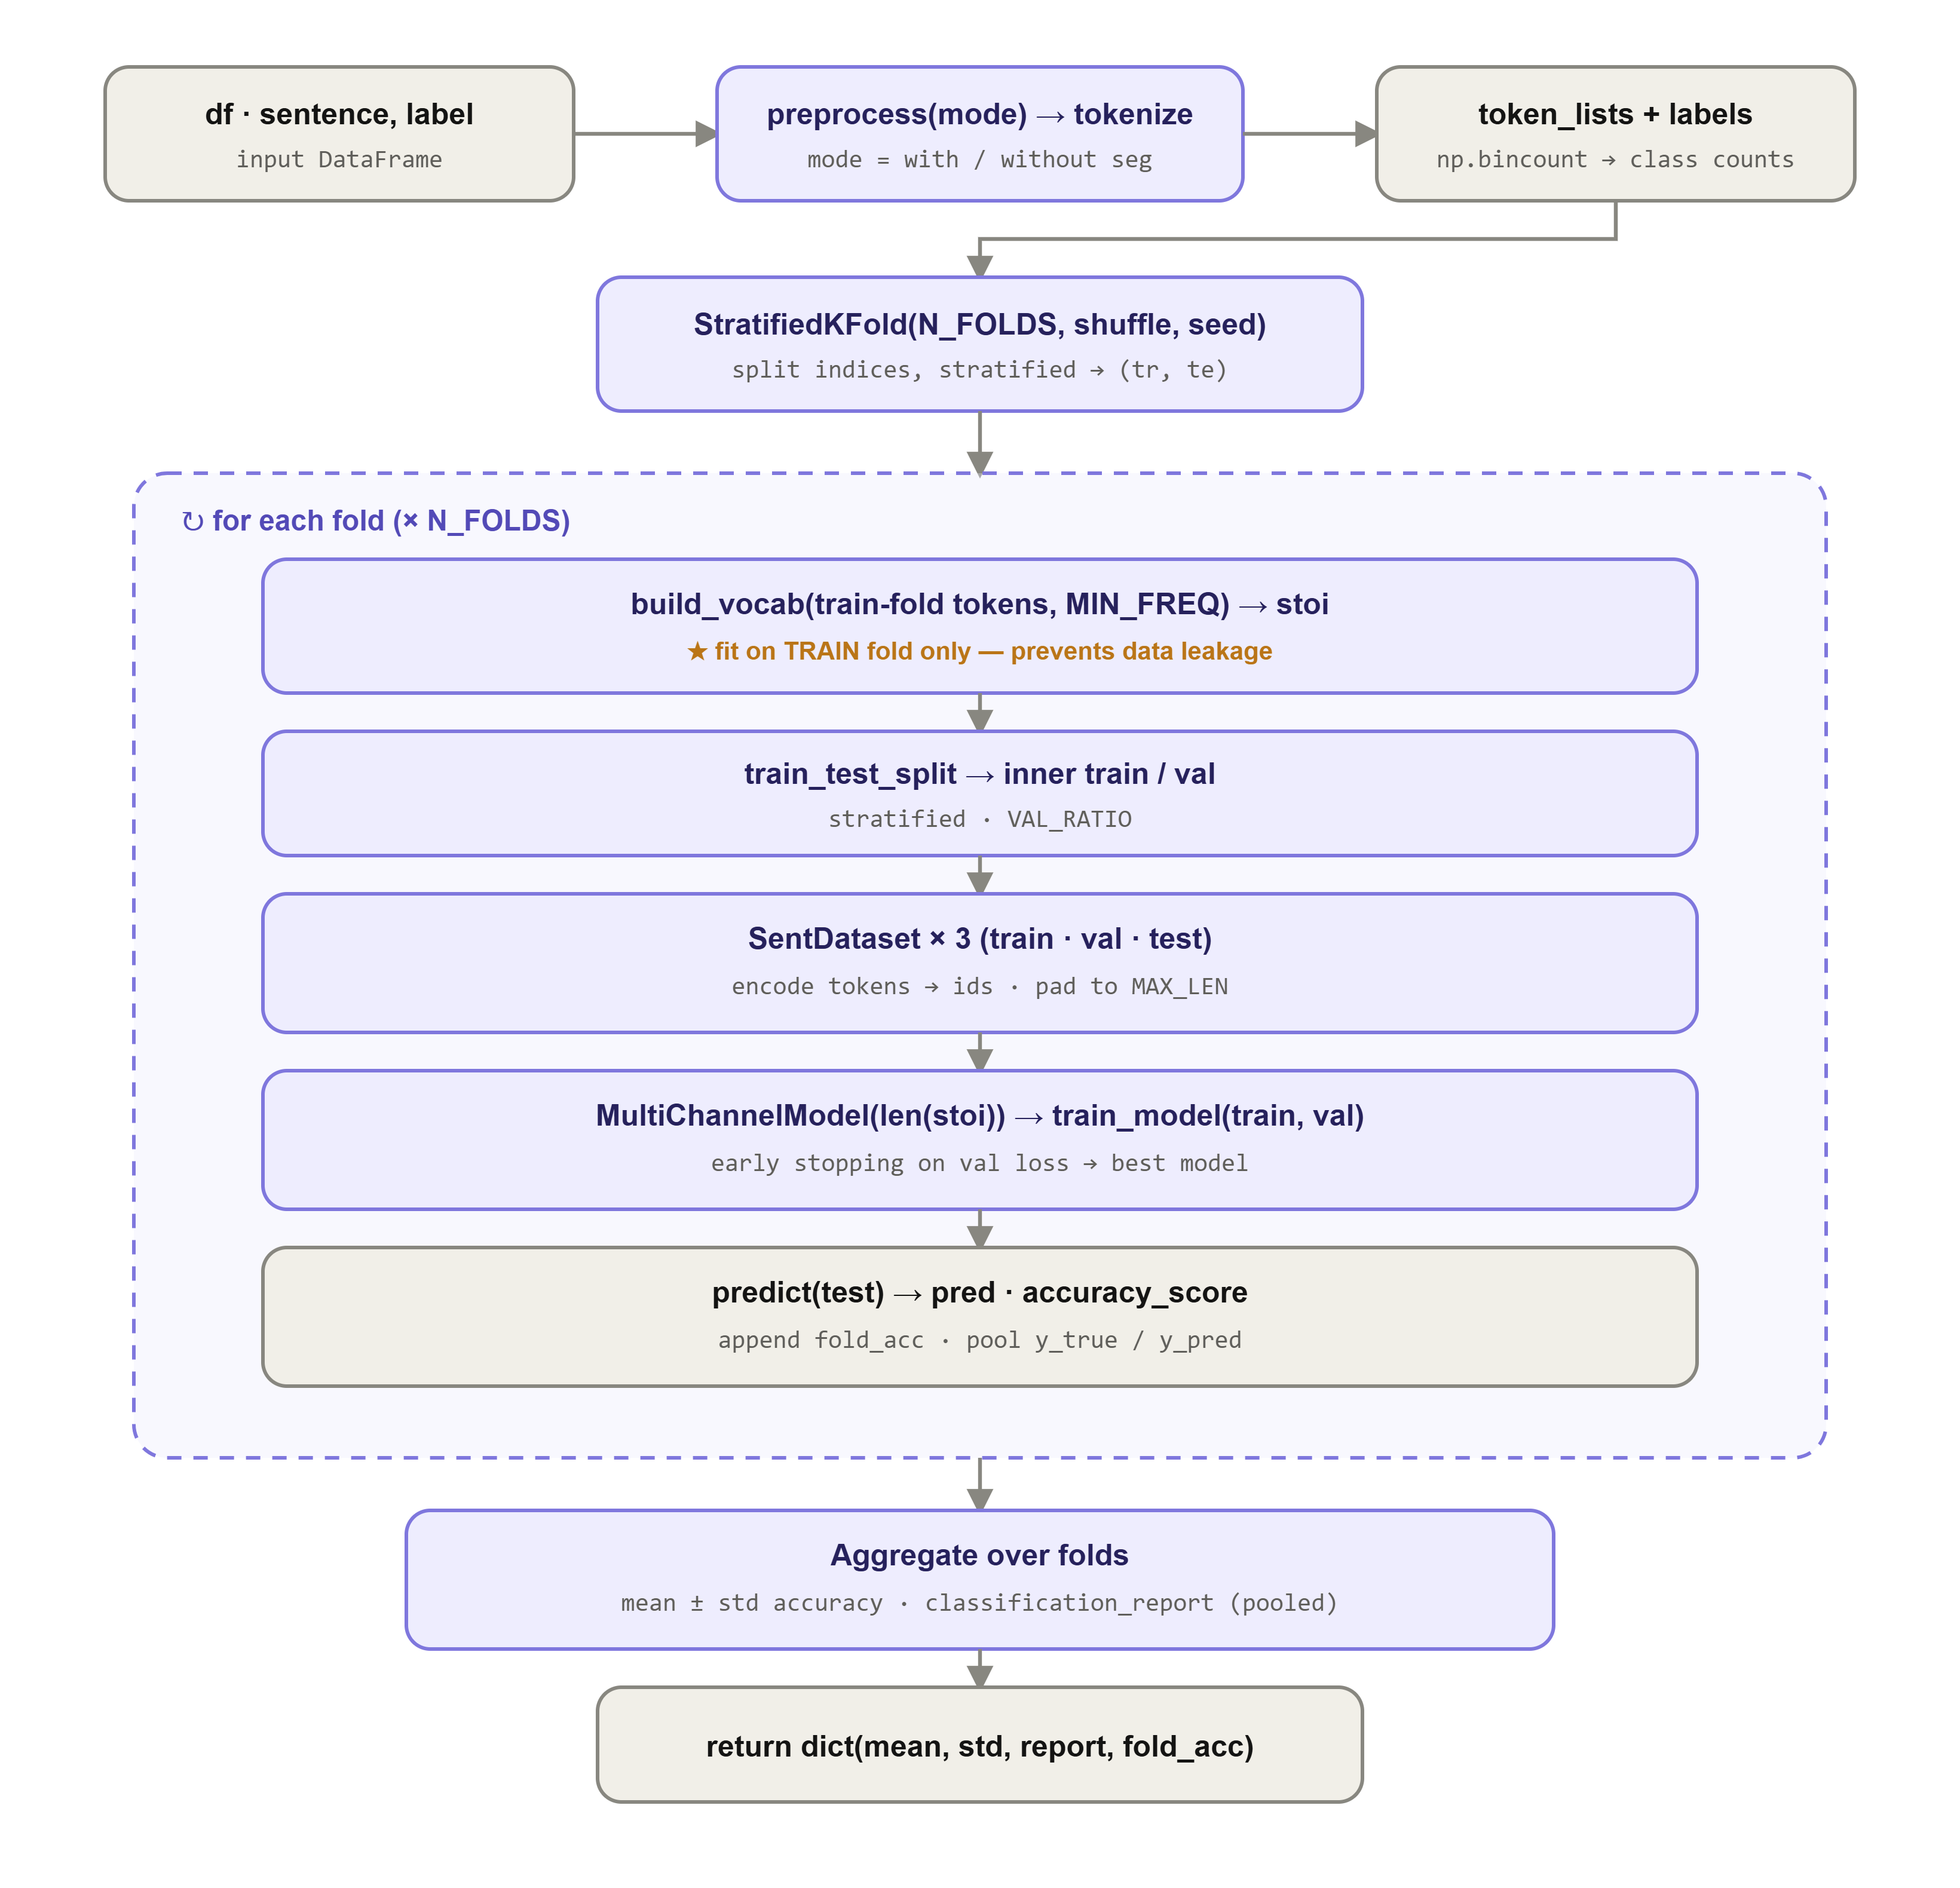

#8. Run it

In [ ]:
results = {}
for mode in CONFIG["SEG_MODES"]:
  results[mode] = run_cv(df, mode, CONFIG, verbose=True)

print("\nDone.")


Preprocessing [without_token]
corpus used: 16175 sentences | class counts (neg, neu, pos) = [7439, 698, 8038]
  per-fold sizes -> train 11646, val 1294, test 3235 | vocab 2672
  fold 1/5  accuracy = 90.48%
  fold 2/5  accuracy = 91.34%
  fold 3/5  accuracy = 90.29%
  fold 4/5  accuracy = 90.45%
  fold 5/5  accuracy = 90.91%
[without_token] mean accuracy = 90.70 +/- 0.38 (224s)

Preprocessing [with_token]
corpus used: 16175 sentences | class counts (neg, neu, pos) = [7439, 698, 8038]
  per-fold sizes -> train 11646, val 1294, test 3235 | vocab 3954
  fold 1/5  accuracy = 90.17%
  fold 2/5  accuracy = 90.23%
  fold 3/5  accuracy = 89.98%
  fold 4/5  accuracy = 89.80%
  fold 5/5  accuracy = 90.48%
[with_token] mean accuracy = 90.13 +/- 0.23 (226s)

Done.


#9. Accuracy

In [ ]:
rows = []
for mode in CONFIG["SEG_MODES"]:
  label = "With token (word segmentation)" if mode == "with_token" else "Without token (syllable)"
  r = results[mode]
  rows.append({
      "Setting": label,
      "Accuracy (%):": f"{r['mean']:.2f} +/- {r['std']:.2f}"
  })
  acc_table = pd.DataFrame(rows).set_index("Setting")
  print("5-fold CV accuracy")
  print(acc_table)

5-fold CV accuracy
                           Accuracy (%):
Setting                                 
Without token (syllable)  90.70 +/- 0.38
5-fold CV accuracy
                                 Accuracy (%):
Setting                                       
Without token (syllable)        90.70 +/- 0.38
With token (word segmentation)  90.13 +/- 0.23


#10. Precision / recall / F1 per class

Computed from the predictions collected over all 5 folds.

In [ ]:
for mode in CONFIG["SEG_MODES"]:
  print(f"per-class report [{mode}]")
  print(results[mode]["report"])
  print()

per-class report [without_token]
              precision    recall  f1-score   support

    negative      0.904     0.937     0.920      7439
     neutral      0.608     0.327     0.425       698
    positive      0.923     0.930     0.926      8038

    accuracy                          0.907     16175
   macro avg      0.812     0.731     0.757     16175
weighted avg      0.901     0.907     0.902     16175


per-class report [with_token]
              precision    recall  f1-score   support

    negative      0.897     0.934     0.915      7439
     neutral      0.567     0.311     0.401       698
    positive      0.922     0.922     0.922      8038

    accuracy                          0.901     16175
   macro avg      0.795     0.722     0.746     16175
weighted avg      0.895     0.901     0.896     16175


